# 初始参数配置

In [15]:
# ============================================
# Jupyter Script: GP 自动挖掘 + 过滤 + 保存
# ============================================

from factors.factor_auto_search import GeneticFactorGenerator
import pandas as pd

# 1) 初始化 GeneticFactorGenerator（基于你给的参数）
fg = GeneticFactorGenerator(
    instrument_id_list='C0',
    start_time='20200101',
    end_time='20241231',
    version='20260403_gp_test',
    calculate_baseline=True,
    max_factor_count=50,
    rolling_norm_clip=5.0,  # 限制最大杠杆比
    gp_generations=30,
    fitness_metric='ic',
    gp_max_depth=4,
    gp_population_size=150,  # 每轮生成的因子数量
    gp_elite_size=30,        # 每轮前gp_elite_size个因子直接保留（不变异）进入下一轮
    gp_elite_relative_threshold=0.75,
    gp_crossover_prob=0.7,
    gp_leaf_prob=0.3,
    gp_const_prob=0.02,
    gp_window_choices=[5, 10, 20],
    gp_depth_penalty_coef=0.0,
    gp_depth_penalty_start_depth=4,
    gp_depth_penalty_linear_coef=0.05,
    gp_depth_penalty_quadratic_coef=0.0,
    gp_early_stopping_generation_count=20,
    random_seed=None,
    # 新增参数（你要求）
    gp_assumed_initial_capital=100000,
    gp_small_factor_penalty_coef=0.0,
    gp_elite_stagnation_generation_count=5,
    gp_max_shock_generation=3,

)

# 2) 过滤阈值（沿用项目内日常脚本的默认思路）
filter_indicator_dict = {
    'Net Return': (0.05, 0.03, 1),
    'Net Sharpe': (0.5, 0.3, 1),
}

# 3) 一键执行：自动挖掘 + 筛选 + 保存
result = fg.auto_mine_select_and_save_fc(
    filter_indicator_dict=filter_indicator_dict,
    n_jobs=5,
    require_all_row=True,
    require_all_instruments=True,
)

# 4) 查看结果
print("config_path:", result.get("config_path"))
print("selected_count:", len(result.get("selected_fc_name_list", [])))
print("selected_fc_name_list:", result.get("selected_fc_name_list", []))

bt = result.get("bt")
if bt is not None and getattr(bt, "performance_summary", None) is not None:
    print("\nperformance_summary tail:")
    display(bt.performance_summary.tail(10))

/Users/wenglongao/anaconda3/envs/future/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/wenglongao/anaconda3/envs/future/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


config_path: None
selected_count: 0
selected_fc_name_list: []

performance_summary tail:


,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2022,0.028600,-0.037152,0.142901,0.142853,0.200142,-0.260070,0.235303,-0.312511,0.120816,0.161368,...,"0.161368(0.15486,0.122289)","0.200142(0.267796,-0.267796)","-0.26007(0.267796,-0.267796)","0.504132(0.516529,0.466942)","0.466942(0.516529,0.466942)","1.30461(0,0)",fac_gp_0049,1d,0.0002,C0
2023,0.088478,0.027714,0.113310,0.113257,0.780850,0.244700,0.958965,0.304445,0.079918,0.095157,...,"0.0951571(0.146334,0.115003)","0.78085(-1.08921,1.08921)","0.2447(-1.08921,1.08921)","0.454545(0.483471,0.491736)","0.442149(0.483471,0.491736)","1.20563(0,0)",fac_gp_0049,1d,0.0002,C0
2024,-0.248167,-0.309813,0.124829,0.125537,-1.988045,-2.467897,-1.903598,-2.429764,0.247195,0.287876,...,"0.287876(0.176943,0.0575955)","-1.98804(-1.37663,1.37663)","-2.4679(-1.37663,1.37663)","0.471074(0.417355,0.541322)","0.454545(0.417355,0.541322)","1.22314(0,0)",fac_gp_0049,1d,0.0002,C0
all,0.027995,-0.033461,0.126634,0.126761,0.221068,-0.263970,0.265860,-0.322287,0.247195,0.344604,...,"0.344604(0.30725,0.362493)","0.221068(0.176769,-0.176769)","-0.26397(0.176421,-0.177116)","0.471947(0.495875,0.480198)","0.450495(0.495875,0.480198)","1.21937(0.000825083,0.000825083)",fac_gp_0049,1d,0.0002,C0
2020,0.010397,-0.049843,0.122264,0.122306,0.085035,-0.407529,0.120762,-0.581114,0.097038,0.123665,...,"0.123665(0.0487138,0.291679)","0.085035(2.75956,-2.75956)","-0.407529(2.75777,-2.76134)","0.411523(0.563786,0.411523)","0.386831(0.563786,0.411523)","1.19524(0.00411523,0.00411523)",fac_gp_0050,1d,0.0002,C0
2021,0.259780,0.200887,0.126989,0.126968,2.045688,1.582189,2.977077,2.305838,0.058819,0.070962,...,"0.0709618(0.148106,0.111244)","2.04569(0.0391665,-0.0391665)","1.58219(0.0391665,-0.0391665)","0.518519(0.497942,0.489712)","0.502058(0.497942,0.489712)","1.16852(0,0)",fac_gp_0050,1d,0.0002,C0
2022,0.028600,-0.037152,0.142901,0.142853,0.200142,-0.260070,0.235303,-0.312511,0.120816,0.161368,...,"0.161368(0.15486,0.122289)","0.200142(0.267796,-0.267796)","-0.26007(0.267796,-0.267796)","0.504132(0.516529,0.466942)","0.466942(0.516529,0.466942)","1.30461(0,0)",fac_gp_0050,1d,0.0002,C0
2023,0.088478,0.027714,0.113310,0.113257,0.780850,0.244700,0.958965,0.304445,0.079918,0.095157,...,"0.0951571(0.146334,0.115003)","0.78085(-1.08921,1.08921)","0.2447(-1.08921,1.08921)","0.454545(0.483471,0.491736)","0.442149(0.483471,0.491736)","1.20563(0,0)",fac_gp_0050,1d,0.0002,C0
2024,-0.248167,-0.309813,0.124829,0.125537,-1.988045,-2.467897,-1.903598,-2.429764,0.247195,0.287876,...,"0.287876(0.176943,0.0575955)","-1.98804(-1.37663,1.37663)","-2.4679(-1.37663,1.37663)","0.471074(0.417355,0.541322)","0.454545(0.417355,0.541322)","1.22314(0,0)",fac_gp_0050,1d,0.0002,C0


In [16]:
import random
rng = random.Random(None)
rng.random()

0.20076583099745104

# 提高随机性参数配置

In [33]:
# ============================================
# Jupyter Script: GP 自动挖掘 + 过滤 + 保存
# ============================================

from factors.factor_auto_search import GeneticFactorGenerator
import pandas as pd

# 1) 初始化 GeneticFactorGenerator（基于你给的参数）
fg = GeneticFactorGenerator(
    instrument_id_list='C0',
    start_time='20200101',
    end_time='20241231',
    version='20260407_gp_test_1',
    calculate_baseline=True,
    max_factor_count=50,
    rolling_norm_clip=5.0,  # 限制最大杠杆比
    gp_generations=60,
    fitness_metric='ic',
    gp_max_depth=6,
    gp_population_size=500,  # 每轮生成的因子数量
    gp_elite_size=50,        # 每轮前gp_elite_size个因子直接保留（不变异）进入下一轮
    gp_elite_relative_threshold=0.65,
    gp_crossover_prob=0.3,
    gp_leaf_prob=0.2,
    gp_const_prob=0.02,
    gp_mutation_prob=0.7,
    gp_tournament_size=3,
    gp_window_choices=[3, 5, 10, 20, 30],
    gp_depth_penalty_coef=0.0,
    gp_depth_penalty_start_depth=6,
    gp_depth_penalty_linear_coef=0.03,
    gp_depth_penalty_quadratic_coef=0.0,
    gp_early_stopping_generation_count=20,
    random_seed=None,
    # 新增参数（你要求）
    gp_assumed_initial_capital=100000,
    gp_small_factor_penalty_coef=0.0,
    gp_elite_stagnation_generation_count=4,
    gp_max_shock_generation=3,

)

# 2) 过滤阈值（沿用项目内日常脚本的默认思路）
filter_indicator_dict = {
    'Net Return': (0.05, 0.03, 1),
    'Net Sharpe': (0.5, 0.3, 1),
}

# 3) 一键执行：自动挖掘 + 筛选 + 保存
result = fg.auto_mine_select_and_save_fc(
    filter_indicator_dict=filter_indicator_dict,
    n_jobs=5,
    require_all_row=True,
    require_all_instruments=True,
)

# 4) 查看结果
print("config_path:", result.get("config_path"))
print("selected_count:", len(result.get("selected_fc_name_list", [])))
print("selected_fc_name_list:", result.get("selected_fc_name_list", []))

bt = result.get("bt")
if bt is not None and getattr(bt, "performance_summary", None) is not None:
    print("\nperformance_summary tail:")
    display(bt.performance_summary.tail(10))

/Users/wenglongao/anaconda3/envs/future/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/wenglongao/anaconda3/envs/future/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Users/wenglongao/work_repo/lionet/factors/factor_ops.py:685: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  return _group_apply_series(df, self.child.calc(df), lambda x: x.pct_change(self.window))
/Users/wenglongao/work_repo/lionet/factors/factor_ops.py:685: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any 

config_path: factors.genetic_programming@20260407_gp_test_1
selected_count: 11
selected_fc_name_list: ['fac_gp_0002', 'fac_gp_0005', 'fac_gp_0006', 'fac_gp_0007', 'fac_gp_0013', 'fac_gp_0024', 'fac_gp_0025', 'fac_gp_0033', 'fac_gp_0038', 'fac_gp_0046', 'fac_gp_0048']

performance_summary tail:


,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2022,0.284789,0.250895,0.113173,0.113081,2.516409,2.218729,3.613963,3.185253,0.054431,0.056634,...,"0.0566342(0.15486,0.122289)","2.51641(0.267796,-0.267796)","2.21873(0.267796,-0.267796)","0.495868(0.516529,0.466942)","0.487603(0.516529,0.466942)","0.672484(0,0)",fac_gp_0049,1d,0.0002,C0
2023,0.226155,0.186872,0.118215,0.118065,1.913088,1.582787,2.638823,2.223790,0.091201,0.095926,...,"0.0959256(0.146334,0.115003)","1.91309(-1.08921,1.08921)","1.58279(-1.08921,1.08921)","0.495868(0.483471,0.491736)","0.475207(0.483471,0.491736)","0.779428(0,0)",fac_gp_0049,1d,0.0002,C0
2024,-0.005742,-0.045146,0.107519,0.107585,-0.053406,-0.419628,-0.061209,-0.491391,0.117562,0.127740,...,"0.12774(0.176943,0.0575955)","-0.0534062(-1.37663,1.37663)","-0.419628(-1.37663,1.37663)","0.433884(0.417355,0.541322)","0.42562(0.417355,0.541322)","0.781817(0,0)",fac_gp_0049,1d,0.0002,C0
all,0.124003,0.088757,0.115794,0.115829,1.070887,0.766275,1.316850,0.955062,0.134200,0.148800,...,"0.1488(0.30725,0.362493)","1.07089(0.176769,-0.176769)","0.766275(0.176421,-0.177116)","0.436469(0.495875,0.480198)","0.426568(0.495875,0.480198)","0.699327(0.000825083,0.000825083)",fac_gp_0049,1d,0.0002,C0
2020,0.045295,0.017995,0.103341,0.103517,0.438303,0.173837,0.581074,0.230824,0.090705,0.101895,...,"0.101895(0.0487138,0.291679)","0.438303(2.75956,-2.75956)","0.173837(2.75777,-2.76134)","0.44856(0.563786,0.411523)","0.440329(0.563786,0.411523)","0.541665(0.00411523,0.00411523)",fac_gp_0050,1d,0.0002,C0
2021,0.156949,0.120447,0.161587,0.161851,0.971303,0.744182,1.061200,0.825643,0.134428,0.148651,...,"0.148651(0.148106,0.111244)","0.971303(0.0391665,-0.0391665)","0.744182(0.0391665,-0.0391665)","0.526749(0.497942,0.489712)","0.510288(0.497942,0.489712)","0.724257(0,0)",fac_gp_0050,1d,0.0002,C0
2022,0.053483,0.013436,0.127538,0.127990,0.419353,0.104980,0.534047,0.134499,0.133948,0.153861,...,"0.153861(0.15486,0.122289)","0.419353(0.267796,-0.267796)","0.10498(0.267796,-0.267796)","0.528926(0.516529,0.466942)","0.512397(0.516529,0.466942)","0.794583(0,0)",fac_gp_0050,1d,0.0002,C0
2023,0.209085,0.169242,0.123049,0.123147,1.699202,1.374310,2.251498,1.848190,0.061542,0.066152,...,"0.0661524(0.146334,0.115003)","1.6992(-1.08921,1.08921)","1.37431(-1.08921,1.08921)","0.520661(0.483471,0.491736)","0.504132(0.483471,0.491736)","0.790535(0,0)",fac_gp_0050,1d,0.0002,C0
2024,0.223185,0.184098,0.126345,0.125781,1.766476,1.463636,2.927999,2.448777,0.086290,0.092683,...,"0.0926827(0.176943,0.0575955)","1.76648(-1.37663,1.37663)","1.46364(-1.37663,1.37663)","0.487603(0.417355,0.541322)","0.475207(0.417355,0.541322)","0.775549(0,0)",fac_gp_0050,1d,0.0002,C0


In [34]:
    # 总体概括
bt = result['bt']
df_all = bt.performance_summary.loc[bt.performance_summary.index == 'all']
df_all = df_all.sort_values(by='Net Sharpe', ascending=False)
print(len(df_all['Factor Name'].tolist()))
top_fc_name = df_all['Factor Name'].tolist()[:10]
selected_fc_name_list = result['selected_fc_name_list']
print(len(selected_fc_name_list))

50
11


In [35]:
# 检查每年指标
df = bt.performance_summary.loc[bt.performance_summary.index != 'all'].reset_index()
check1 = df.groupby('Factor Name').apply(lambda x: all(x['Net Sharpe'] >= 0.3), include_groups=False).sort_values(ascending=False)
check2 = df.groupby('Factor Name').apply(lambda x: all(x['Net Return'] >= 0.03), include_groups=False).sort_values(ascending=False)
print(check1)

Factor Name
fac_gp_0046     True
fac_gp_0048     True
fac_gp_0005     True
fac_gp_0006     True
fac_gp_0007     True
fac_gp_0002     True
fac_gp_0038     True
fac_gp_0025     True
fac_gp_0024     True
fac_gp_0033     True
fac_gp_0013     True
fac_gp_0035    False
fac_gp_0036    False
fac_gp_0001    False
fac_gp_0034    False
fac_gp_0032    False
fac_gp_0037    False
fac_gp_0041    False
fac_gp_0039    False
fac_gp_0040    False
fac_gp_0030    False
fac_gp_0042    False
fac_gp_0043    False
fac_gp_0044    False
fac_gp_0045    False
fac_gp_0047    False
fac_gp_0049    False
fac_gp_0031    False
fac_gp_0026    False
fac_gp_0029    False
fac_gp_0015    False
fac_gp_0003    False
fac_gp_0004    False
fac_gp_0008    False
fac_gp_0009    False
fac_gp_0010    False
fac_gp_0011    False
fac_gp_0012    False
fac_gp_0014    False
fac_gp_0016    False
fac_gp_0028    False
fac_gp_0017    False
fac_gp_0018    False
fac_gp_0019    False
fac_gp_0020    False
fac_gp_0021    False
fac_gp_0022    False
f

In [36]:
print(check2)

Factor Name
fac_gp_0002     True
fac_gp_0048     True
fac_gp_0005     True
fac_gp_0006     True
fac_gp_0007     True
fac_gp_0033     True
fac_gp_0046     True
fac_gp_0038     True
fac_gp_0025     True
fac_gp_0024     True
fac_gp_0013     True
fac_gp_0016     True
fac_gp_0035    False
fac_gp_0036    False
fac_gp_0001    False
fac_gp_0034    False
fac_gp_0032    False
fac_gp_0037    False
fac_gp_0041    False
fac_gp_0039    False
fac_gp_0040    False
fac_gp_0030    False
fac_gp_0042    False
fac_gp_0043    False
fac_gp_0044    False
fac_gp_0045    False
fac_gp_0047    False
fac_gp_0049    False
fac_gp_0031    False
fac_gp_0026    False
fac_gp_0029    False
fac_gp_0028    False
fac_gp_0003    False
fac_gp_0004    False
fac_gp_0008    False
fac_gp_0009    False
fac_gp_0010    False
fac_gp_0011    False
fac_gp_0012    False
fac_gp_0014    False
fac_gp_0015    False
fac_gp_0017    False
fac_gp_0018    False
fac_gp_0019    False
fac_gp_0020    False
fac_gp_0021    False
fac_gp_0022    False
f

In [37]:
# 检查年化平均指标
check3 = df.groupby('Factor Name')['Net Sharpe'].mean().sort_values(ascending=False)
print(check3)

Factor Name
fac_gp_0003    1.549276
fac_gp_0008    1.516139
fac_gp_0001    1.503875
fac_gp_0048    1.484200
fac_gp_0005    1.438359
fac_gp_0045    1.427562
fac_gp_0038    1.424934
fac_gp_0013    1.399292
fac_gp_0025    1.397376
fac_gp_0014    1.300248
fac_gp_0012    1.240511
fac_gp_0020    1.214451
fac_gp_0033    1.122904
fac_gp_0017    1.114449
fac_gp_0015    1.101498
fac_gp_0011    1.098266
fac_gp_0046    1.078490
fac_gp_0010    1.073411
fac_gp_0007    1.063297
fac_gp_0034    1.056569
fac_gp_0024    1.041189
fac_gp_0022    1.007419
fac_gp_0002    0.977559
fac_gp_0029    0.947703
fac_gp_0041    0.934938
fac_gp_0016    0.898760
fac_gp_0006    0.876023
fac_gp_0019    0.872336
fac_gp_0044    0.869992
fac_gp_0040    0.823816
fac_gp_0030    0.820483
fac_gp_0031    0.820409
fac_gp_0004    0.789556
fac_gp_0035    0.785054
fac_gp_0023    0.781706
fac_gp_0050    0.772189
fac_gp_0047    0.768125
fac_gp_0018    0.761357
fac_gp_0042    0.751336
fac_gp_0049    0.730504
fac_gp_0027    0.686616
fac_

In [38]:
check4 = df.groupby('Factor Name')['Net Return'].mean().sort_values(ascending=False)
print(check4)

Factor Name
fac_gp_0038    0.219427
fac_gp_0003    0.203127
fac_gp_0025    0.184508
fac_gp_0046    0.178171
fac_gp_0005    0.168719
fac_gp_0008    0.158165
fac_gp_0017    0.150968
fac_gp_0012    0.149261
fac_gp_0001    0.147293
fac_gp_0013    0.146115
fac_gp_0034    0.143935
fac_gp_0014    0.142691
fac_gp_0048    0.142289
fac_gp_0024    0.134342
fac_gp_0007    0.134329
fac_gp_0045    0.132415
fac_gp_0020    0.130242
fac_gp_0033    0.129494
fac_gp_0011    0.121042
fac_gp_0015    0.114930
fac_gp_0041    0.112845
fac_gp_0047    0.111519
fac_gp_0010    0.110743
fac_gp_0022    0.110359
fac_gp_0030    0.104875
fac_gp_0006    0.103545
fac_gp_0016    0.103127
fac_gp_0050    0.101044
fac_gp_0002    0.098792
fac_gp_0035    0.096719
fac_gp_0029    0.095325
fac_gp_0040    0.094233
fac_gp_0044    0.090943
fac_gp_0031    0.090421
fac_gp_0004    0.089634
fac_gp_0049    0.088861
fac_gp_0018    0.088738
fac_gp_0042    0.087146
fac_gp_0021    0.086982
fac_gp_0023    0.080415
fac_gp_0032    0.075964
fac_

In [39]:
check5 = df.groupby('Factor Name')['TS IC'].mean().sort_values(ascending=False)
print(check5)

Factor Name
fac_gp_0003    0.117684
fac_gp_0008    0.110188
fac_gp_0025    0.106985
fac_gp_0013    0.104901
fac_gp_0001    0.103984
fac_gp_0005    0.103768
fac_gp_0048    0.102424
fac_gp_0014    0.096083
fac_gp_0007    0.094706
fac_gp_0020    0.094263
fac_gp_0012    0.094190
fac_gp_0017    0.093612
fac_gp_0038    0.093421
fac_gp_0046    0.088090
fac_gp_0011    0.087660
fac_gp_0015    0.087166
fac_gp_0033    0.085863
fac_gp_0034    0.084414
fac_gp_0010    0.082792
fac_gp_0006    0.081813
fac_gp_0045    0.081433
fac_gp_0041    0.080998
fac_gp_0030    0.078893
fac_gp_0016    0.076217
fac_gp_0022    0.076021
fac_gp_0047    0.075265
fac_gp_0024    0.073928
fac_gp_0002    0.073147
fac_gp_0044    0.071685
fac_gp_0029    0.071430
fac_gp_0040    0.069738
fac_gp_0035    0.067683
fac_gp_0021    0.067517
fac_gp_0023    0.067055
fac_gp_0031    0.064158
fac_gp_0050    0.064147
fac_gp_0004    0.063898
fac_gp_0042    0.063134
fac_gp_0049    0.062398
fac_gp_0039    0.061233
fac_gp_0019    0.061093
fac_

In [40]:
# 查看公式
for key, value in fg.factor_formula_map.items():
    print(key, value)
    print('=' * 80)

fac_gp_0001 TsCorr(Add(Max(close, open), Mul(close, TsCorr(low, low, 3))), Div(Sub(open, TsMin(close, 5)), LowerShadowRatio(close)), 5)
fac_gp_0002 TsCorr(Mul(close, Inv(TsCorr(low, low, 3))), Div(Sub(open, TsMin(Max(close, open), 5)), LowerShadowRatio(Sub(close, Max(close, high)))), 5)
fac_gp_0003 Neg(TsCorr(Abs(close), Sub(SqrtAbs(low), Div(Sub(open, TsMin(close, 5)), TsBeta(open, low, 5))), 5))
fac_gp_0004 TsCorr(Delta(Add(close, TsMin(high, 10))), Div(Sub(open, TsMin(TypicalPrice(low), 5)), LowerShadowRatio(Sub(low, TsMin(close, 5)))), 5)
fac_gp_0005 TsCorr(Add(TsMin(TsMin(close, 5), 5), Mul(close, Inv(Sig(position)))), Sub(open, TsMin(close, 5)), 5)
fac_gp_0006 Min(Mul(Sig(position), TsArgmin(TypicalPrice(low), 20)), TsArgmax(Delta(Add(Add(open, high), TsMin(close, 30))), 3))
fac_gp_0007 Min(SqrtAbs(Mul(Abs(StochasticK(high)), TsArgmin(TypicalPrice(low), 20))), TsArgmax(Delta(TsMax(high, 5)), 3))
fac_gp_0008 TsCorr(Add(close, TsMin(low, 5)), Div(Sub(open, TsMin(close, 30)), LowerS

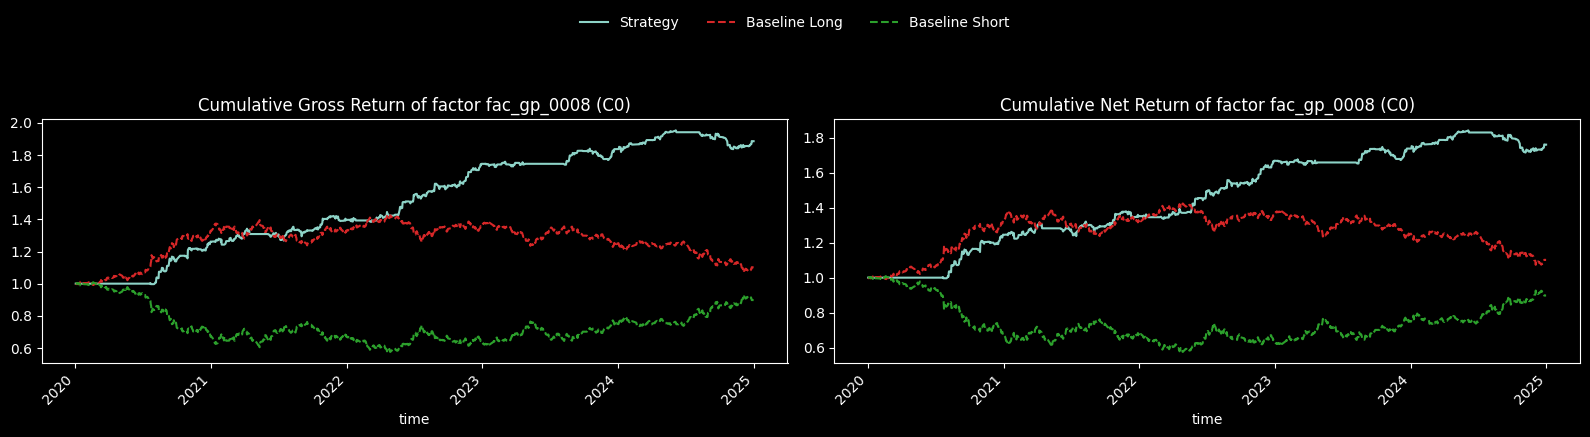

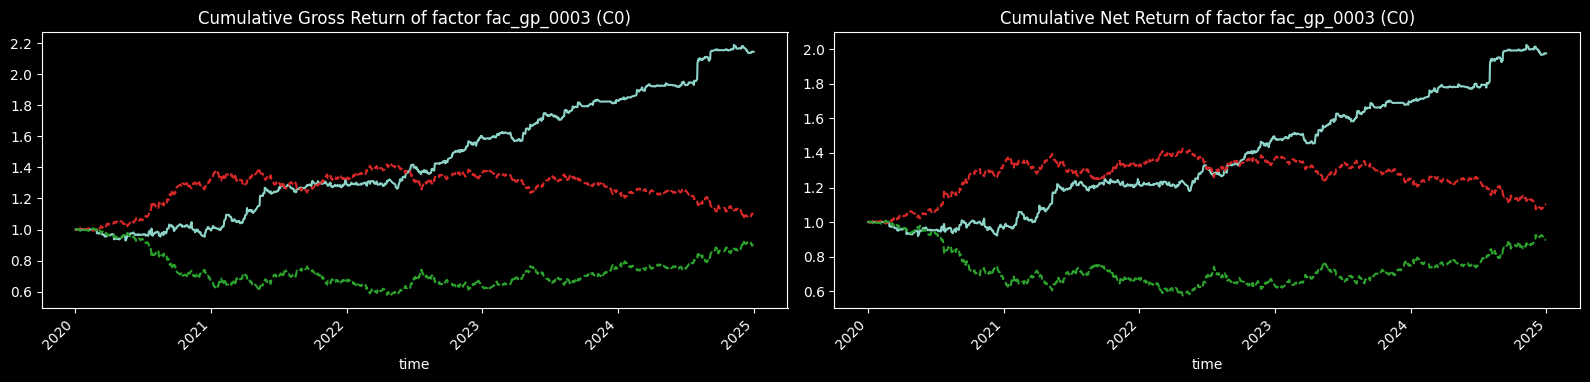

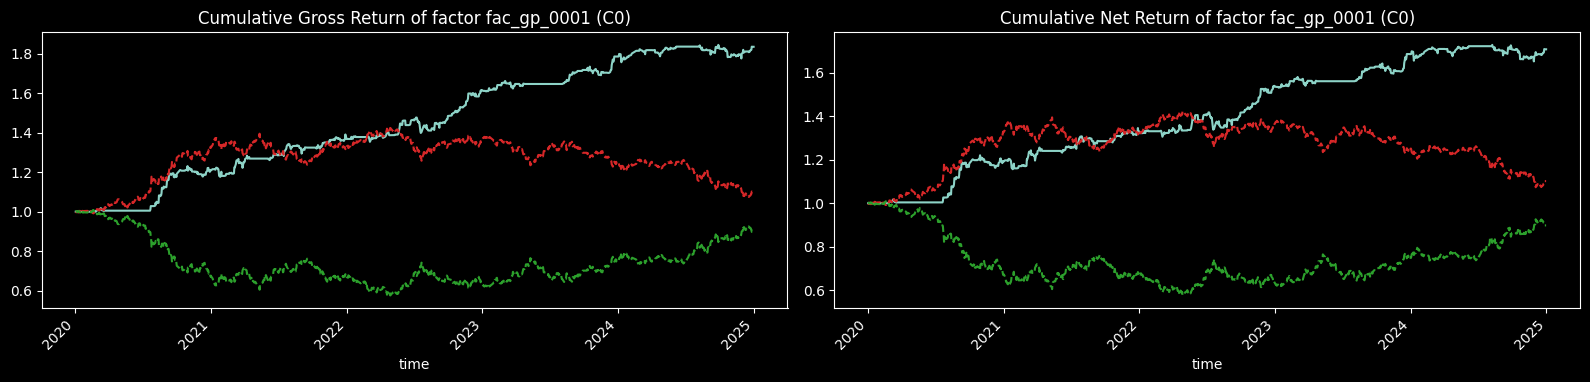

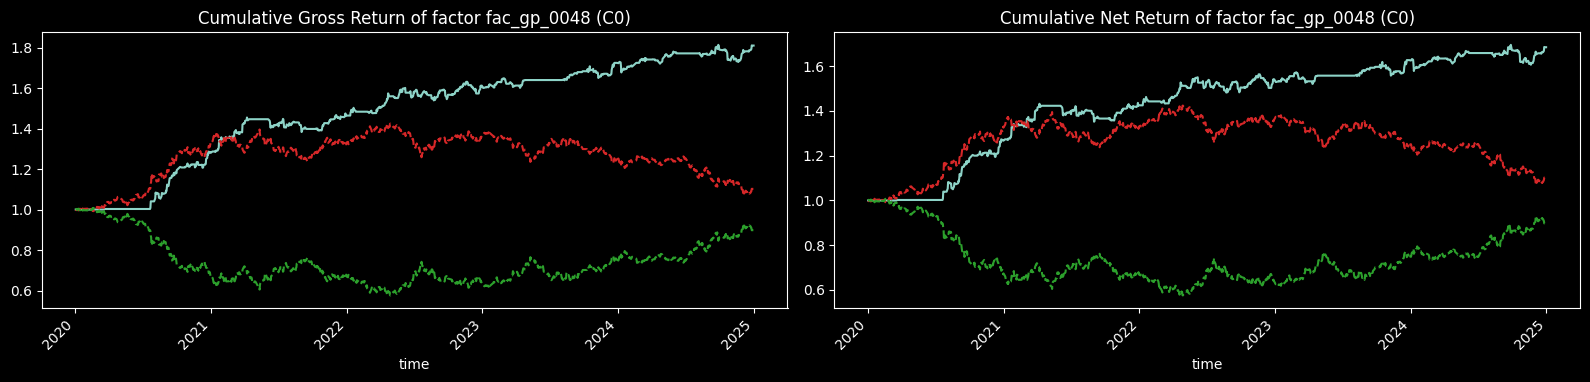

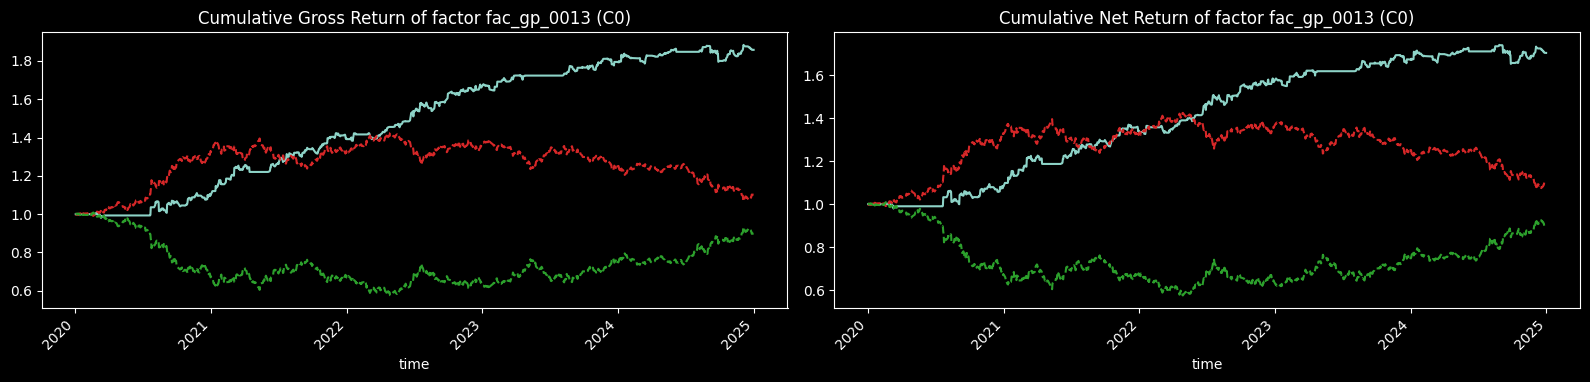

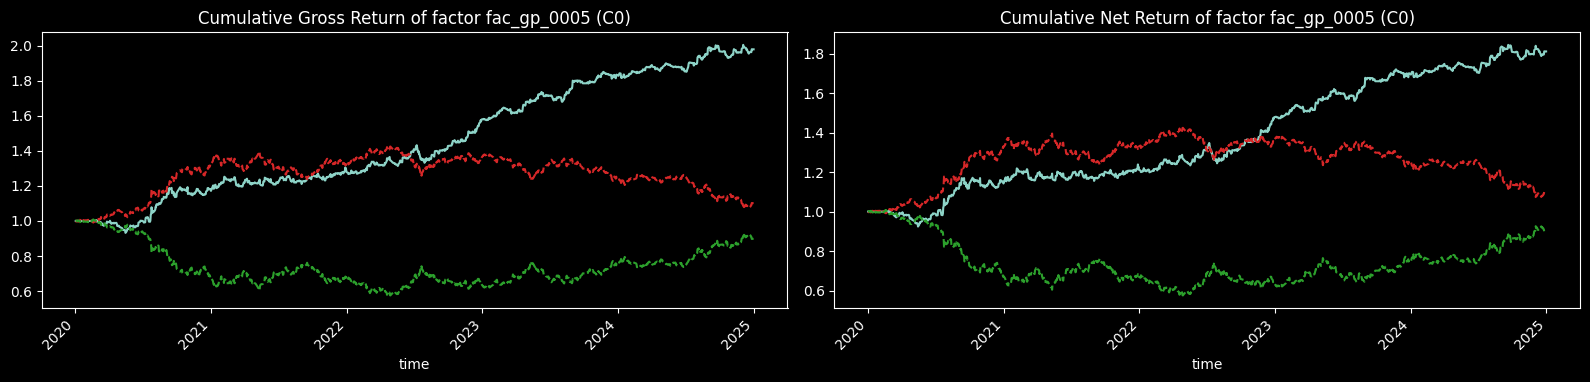

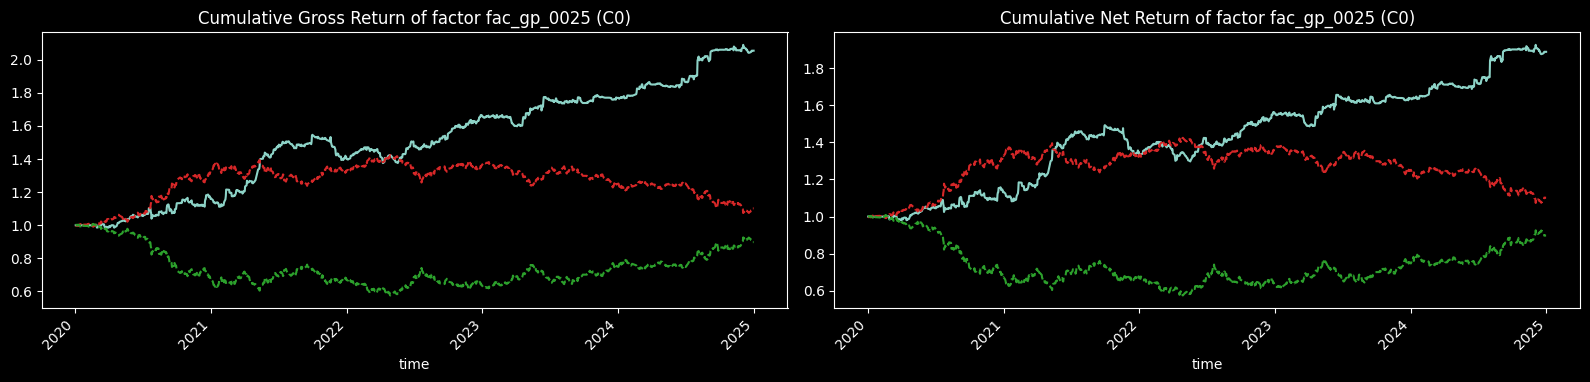

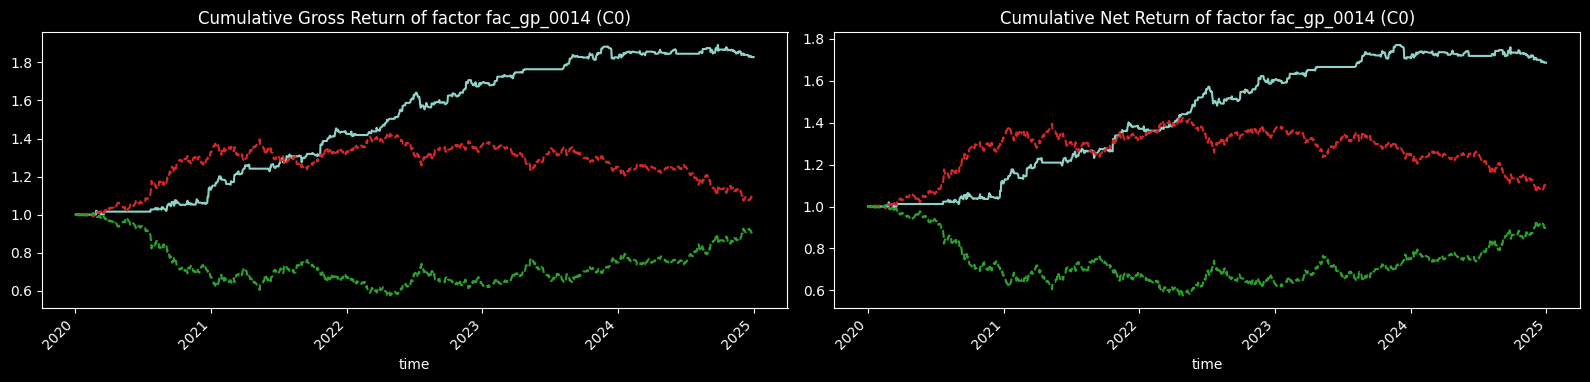

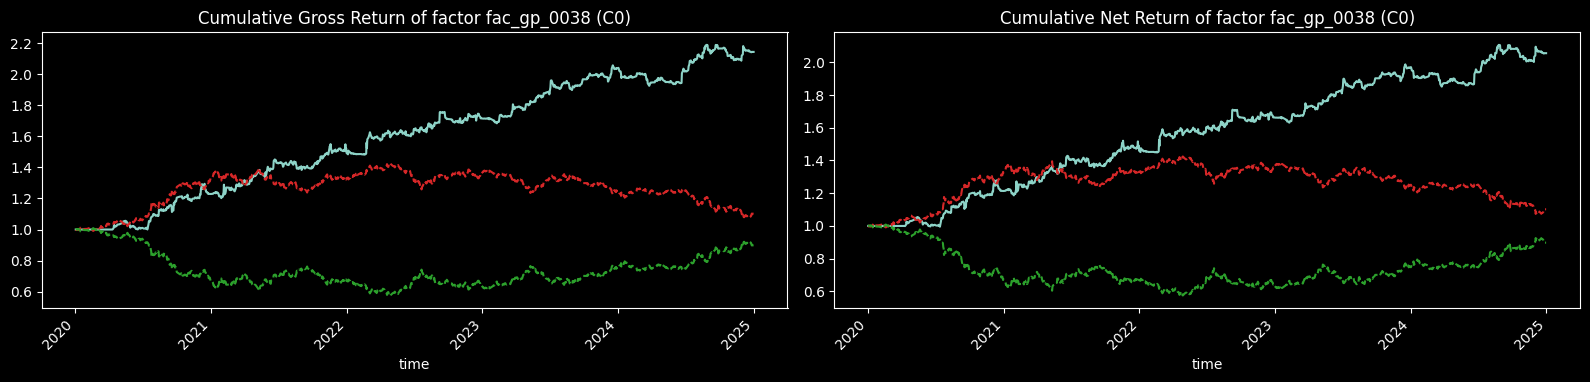

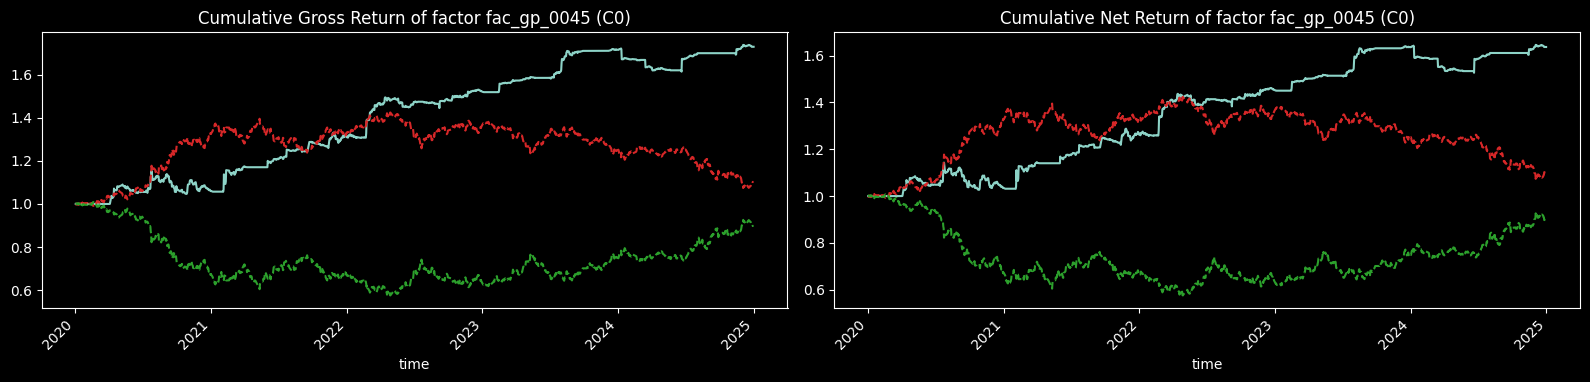

In [41]:
# 净值曲线
start_time = pd.to_datetime('20200101')
end_time = pd.to_datetime('20241231')
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=top_fc_name, show_baseline=True)

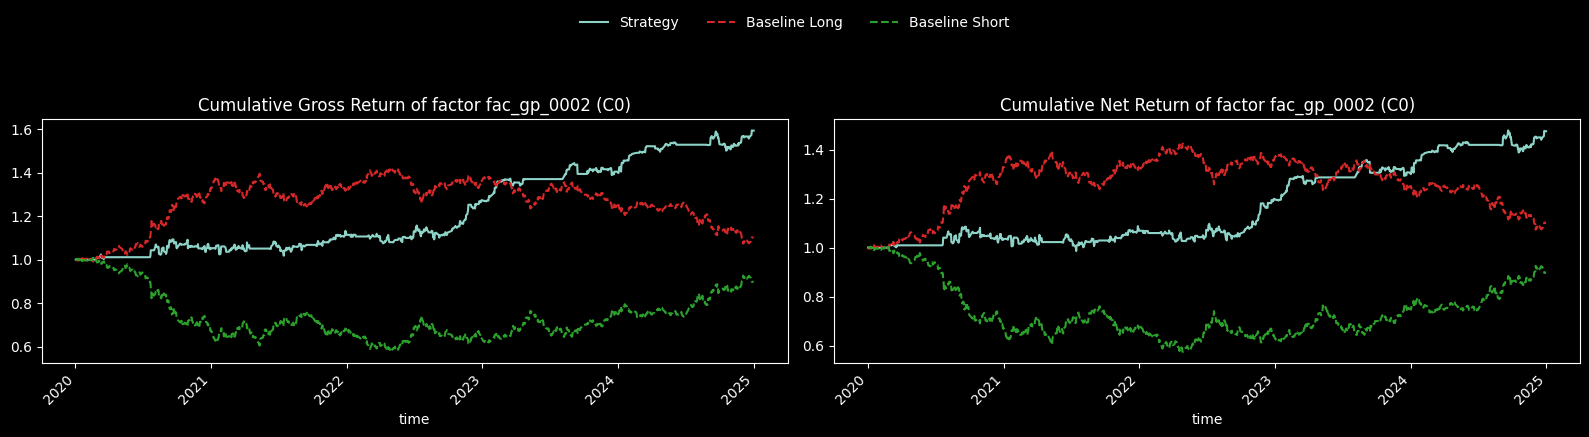

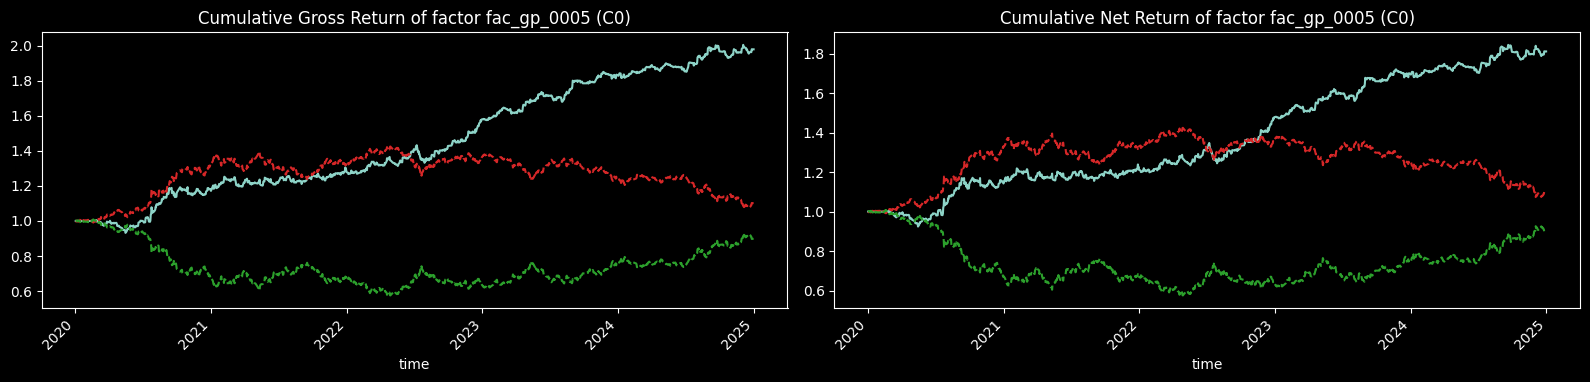

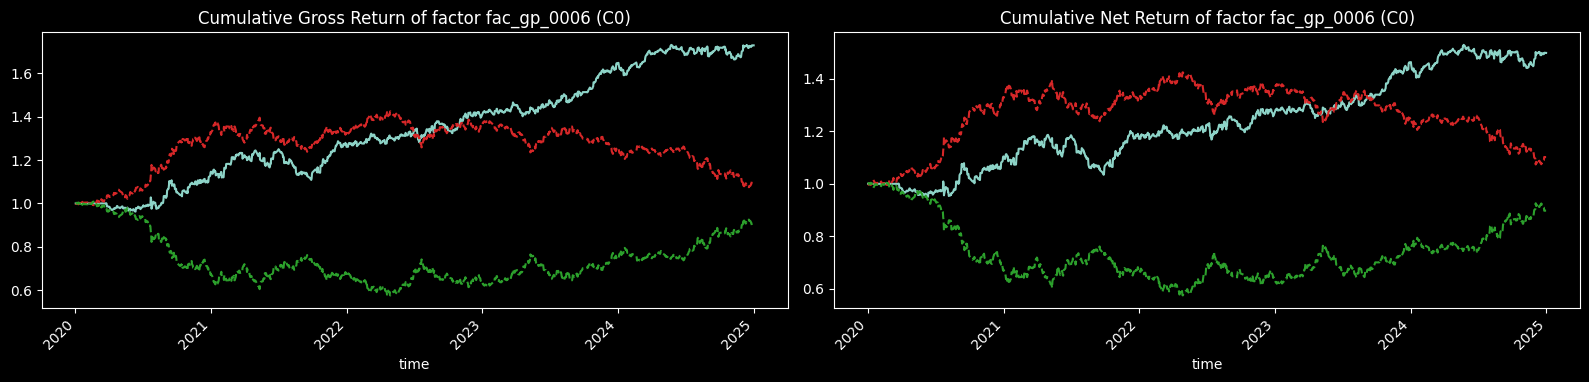

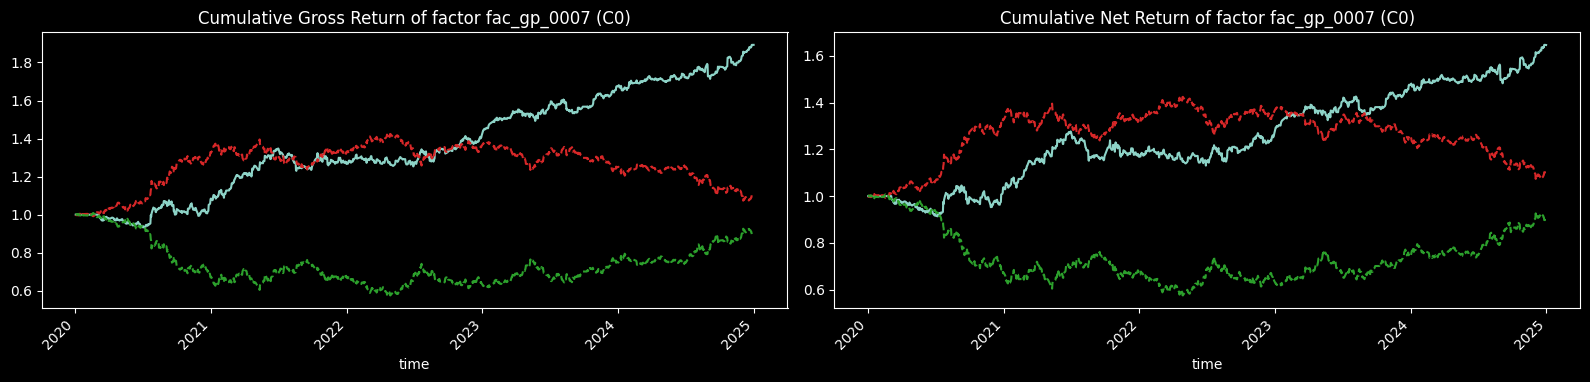

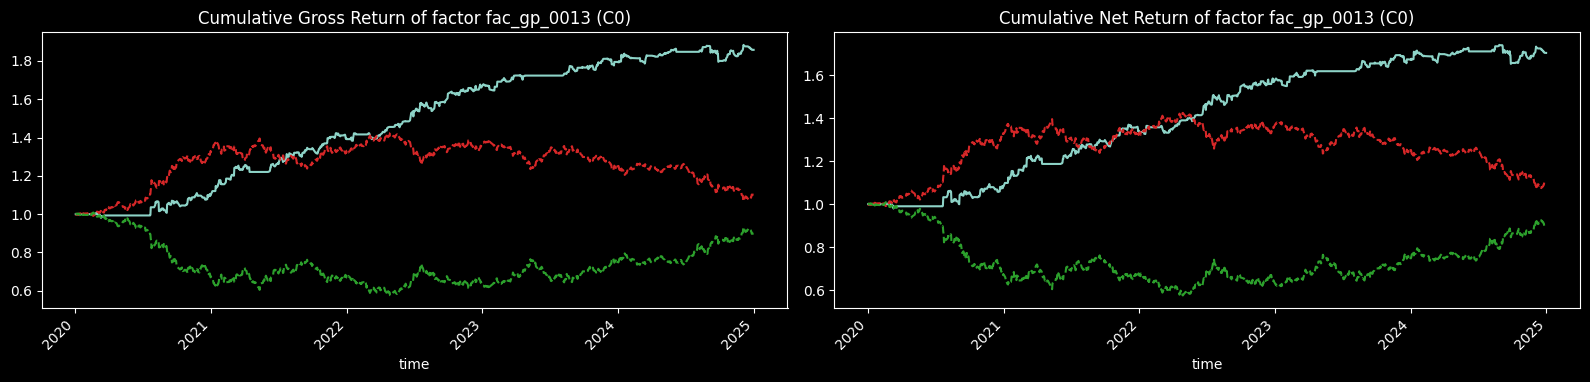

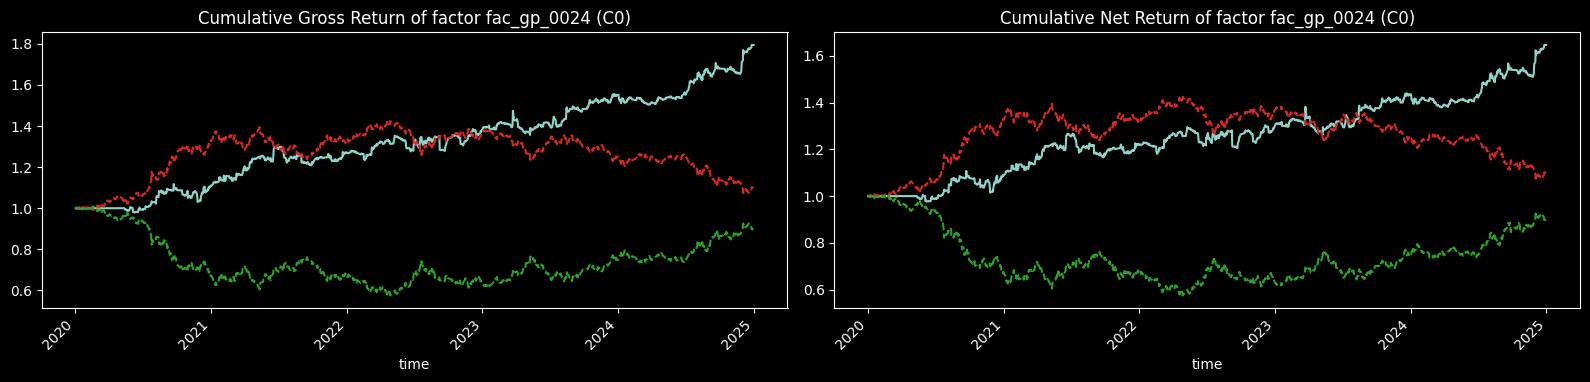

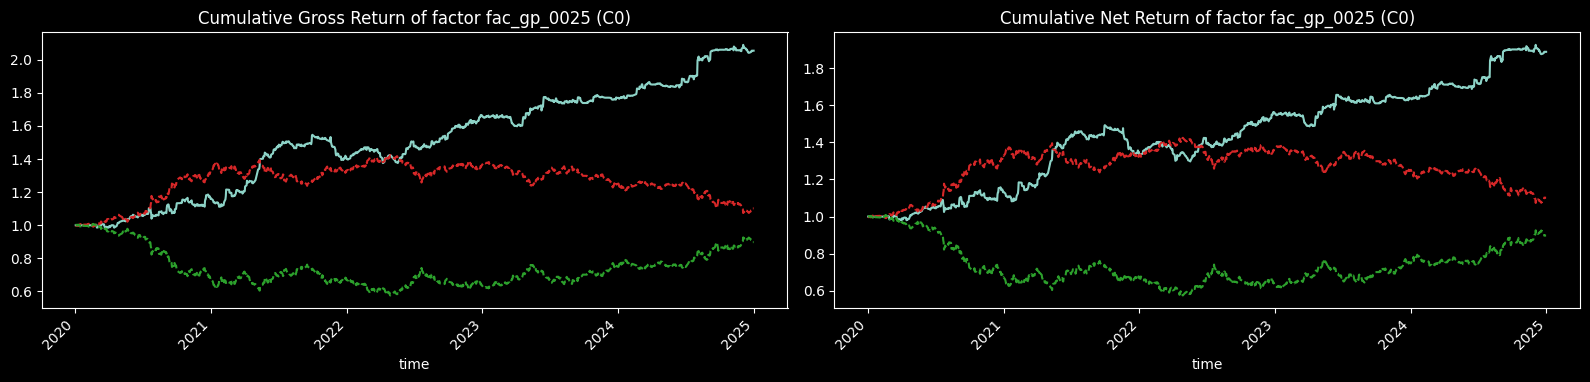

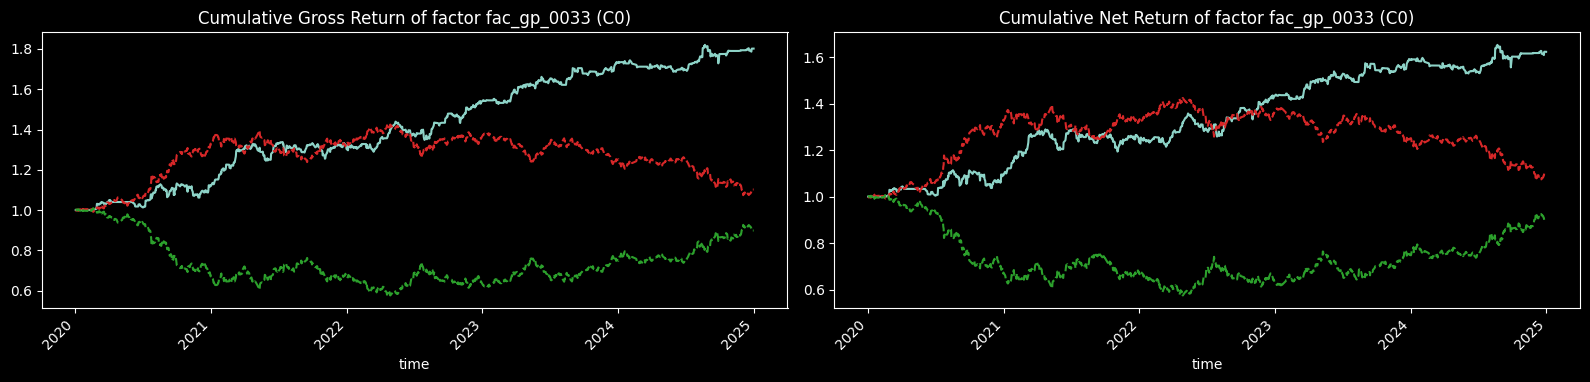

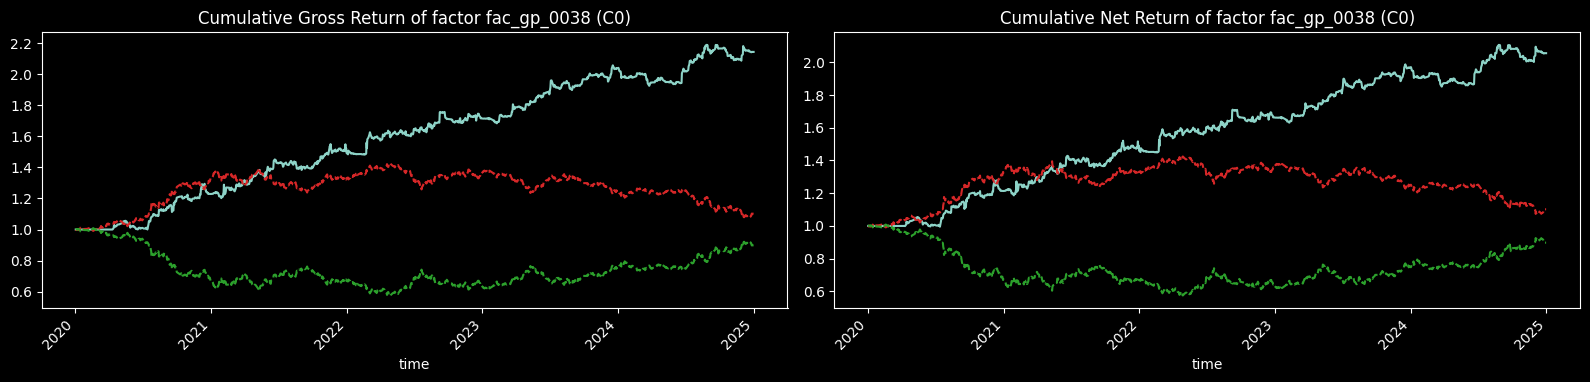

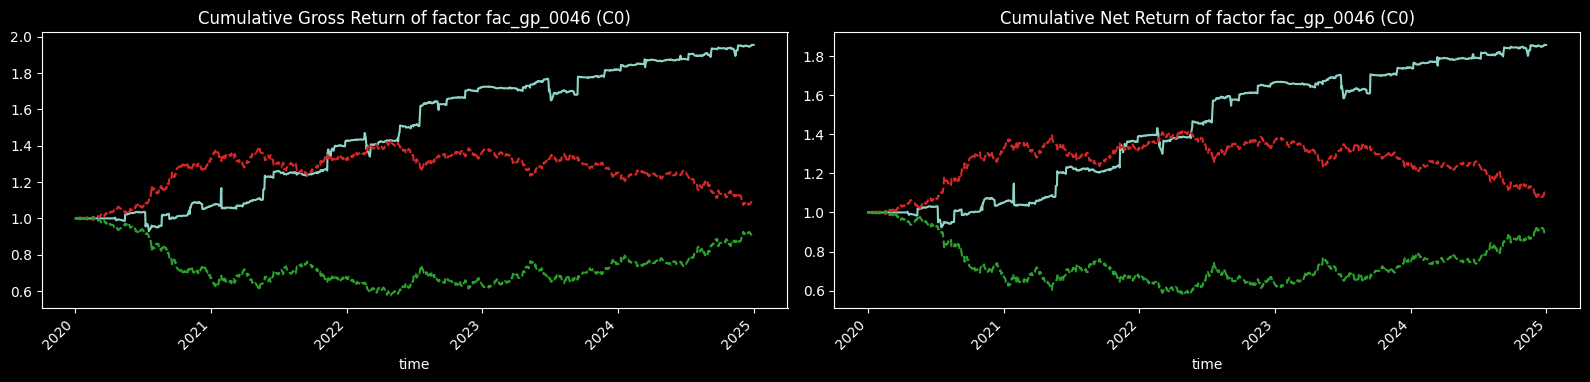

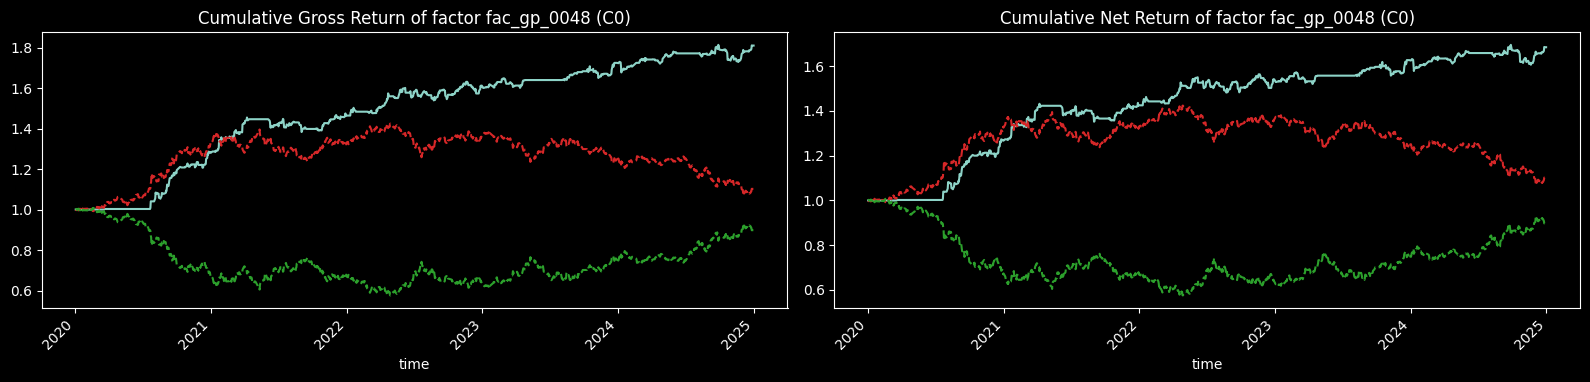

In [42]:
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=selected_fc_name_list, show_baseline=True)

In [ ]:
from datetime import datetime

In [ ]:
date_str = datetime.now().strftime('%Y%m%d')
date_str